# 01 — Data Exploration: NASA IMS Bearing Dataset

**Goal of this notebook.** Get oriented in the dataset before any modelling:

1. Confirm the file layout matches the official spec.
2. Understand what a single 1-second snapshot looks like, raw and in the frequency domain.
3. Visualise the degradation curve across the full run-to-failure experiment.
4. Pick which test set to focus modelling on, and which bearing carries the strongest failure signal.

**Dataset spec** (from the included `Readme Document for IMS Bearing Data.pdf`):

| Set | Files | Channels | Duration | Failure |
|---|---|---|---|---|
| 1 | 2,156 | 8 (2 per bearing, x+y) | Oct 22 – Nov 25, 2003 | inner race (B3), roller element (B4) |
| 2 | 984 | 4 (1 per bearing) | Feb 12–19, 2004 | outer race (B1) |
| 3 | 4,448* | 4 (1 per bearing) | Mar 4 – Apr 4, 2004 | outer race (B3) |

*Local copy has 6,324 files in Set 3 — investigated below.

Each file = 1 second snapshot @ 20 kHz → 20,480 rows × N channels, tab-separated ASCII. Files are recorded every 10 minutes (with a couple of exceptions).

**Focus for this notebook: Set 2.** Smallest (984 files), 4 channels (1-to-1 bearing mapping makes interpretation cleaner), and the failure outcome (bearing 1 outer race) is the most-replicated benchmark in the literature.

In [1]:
from __future__ import annotations

import os
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as scisig
from scipy.stats import kurtosis

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

DATA_ROOT = Path.home() / ".cache/kagglehub/datasets/vinayak123tyagi/bearing-dataset/versions/1"
FIG_DIR = Path(__file__).resolve().parent.parent / "figures" if "__file__" in globals() else Path.cwd().parent / "figures"
FIG_DIR.mkdir(exist_ok=True)

SETS = {
    1: DATA_ROOT / "1st_test" / "1st_test",
    2: DATA_ROOT / "2nd_test" / "2nd_test",
    3: DATA_ROOT / "3rd_test" / "4th_test" / "txt",
}

SAMPLE_RATE_HZ = 20_000
SAMPLES_PER_FILE = 20_480

for n, p in SETS.items():
    print(f"Set {n}: {p}  →  exists={p.exists()}")

Set 1: /Users/rubenelkana/.cache/kagglehub/datasets/vinayak123tyagi/bearing-dataset/versions/1/1st_test/1st_test  →  exists=True
Set 2: /Users/rubenelkana/.cache/kagglehub/datasets/vinayak123tyagi/bearing-dataset/versions/1/2nd_test/2nd_test  →  exists=True
Set 3: /Users/rubenelkana/.cache/kagglehub/datasets/vinayak123tyagi/bearing-dataset/versions/1/3rd_test/4th_test/txt  →  exists=True


## 1. File inventory — sanity check against the spec

In [2]:
def list_snapshot_files(set_dir: Path) -> list[Path]:
    """Return snapshot files sorted by their embedded timestamp."""
    files = [p for p in set_dir.iterdir() if not p.name.startswith(".") and p.is_file()]
    files.sort(key=lambda p: p.name)
    return files


inventory = []
for n, p in SETS.items():
    files = list_snapshot_files(p)
    if files:
        t0 = datetime.strptime(files[0].name, "%Y.%m.%d.%H.%M.%S")
        t1 = datetime.strptime(files[-1].name, "%Y.%m.%d.%H.%M.%S")
        inventory.append({"set": n, "n_files": len(files), "start": t0, "end": t1, "duration_h": round((t1 - t0).total_seconds() / 3600, 1)})

pd.DataFrame(inventory).set_index("set")

,n_files,start,end,duration_h
set,,,,
1,2156,2003-10-22 12:06:24,2003-11-25 23:39:56,827.6
2,984,2004-02-12 10:32:39,2004-02-19 06:22:39,163.8
3,6324,2004-03-04 09:27:46,2004-04-18 02:42:55,1073.3


**Observation.** The local Kaggle copy of Set 3 contains more files than the original spec (4,448). The extras appear to be additional snapshots collected after the originally documented end of experiment. This won't affect modelling; we'll treat the whole sorted timeline as one run-to-failure trajectory and let the failure point emerge from the data.

## 2. Loading helpers and picking representative snapshots

Set 2 has one accelerometer per bearing, so each channel = one bearing. Failure outcome: bearing 1 develops an outer-race defect by end of test.

Naively picking the "last file" as the degraded reference is a trap: the documented experiment ended when bearing 1 failed, but in this Kaggle copy the last files contain near-zero amplitude (test rig shut down after failure). We instead pick the **peak-RMS snapshot on bearing 1** as our degraded reference — that's the actual loudest moment of the failure.

To do that, we need feature extraction first, then we'll return to per-snapshot plots.

In [3]:
def load_snapshot(file_path: Path, n_channels: int | None = None) -> np.ndarray:
    """Load a single 1-second snapshot. Returns (samples, channels) array."""
    arr = np.loadtxt(file_path)
    if arr.ndim == 1:
        arr = arr[:, None]
    if n_channels is not None and arr.shape[1] != n_channels:
        raise ValueError(f"Expected {n_channels} channels, got {arr.shape[1]} in {file_path.name}")
    return arr


def snapshot_features(snap: np.ndarray) -> dict[str, float]:
    """Compute per-channel summary stats. Returns a flat dict keyed by feature_ch."""
    out: dict[str, float] = {}
    for ch in range(snap.shape[1]):
        x = snap[:, ch]
        out[f"rms_b{ch + 1}"] = float(np.sqrt(np.mean(x**2)))
        out[f"kurtosis_b{ch + 1}"] = float(kurtosis(x, fisher=False))
        out[f"peak_b{ch + 1}"] = float(np.max(np.abs(x)))
    return out


set2_files = list_snapshot_files(SETS[2])
print(f"Set 2: {len(set2_files)} snapshots to scan")

Set 2: 984 snapshots to scan


In [4]:
# Scan all Set 2 snapshots — ~30s on a fast laptop.
records = []
for i, f in enumerate(set2_files):
    feats = snapshot_features(load_snapshot(f, n_channels=4))
    feats["timestamp"] = datetime.strptime(f.name, "%Y.%m.%d.%H.%M.%S")
    feats["file_idx"] = i
    records.append(feats)

feat_df = pd.DataFrame(records).set_index("timestamp").sort_index()
print(f"Computed features for {len(feat_df)} snapshots")
feat_df.describe().round(3)

Computed features for 984 snapshots


,rms_b1,kurtosis_b1,peak_b1,rms_b2,kurtosis_b2,peak_b2,rms_b3,kurtosis_b3,peak_b3,rms_b4,kurtosis_b4,peak_b4,file_idx
count,984.000,984.000,984.000,984.000,984.000,984.000,984.000,984.000,984.000,984.000,984.000,984.000,984.000
mean,0.106,3.827,0.555,0.099,3.153,0.479,0.105,4.330,0.771,0.060,3.142,0.278,491.500
std,0.058,0.966,0.388,0.015,0.146,0.072,0.014,0.583,0.118,0.012,0.118,0.056,284.201
min,0.002,1.390,0.005,0.001,1.129,0.002,0.001,1.065,0.005,0.002,2.659,0.005,0.000
25%,0.077,3.394,0.393,0.093,3.112,0.435,0.099,4.073,0.688,0.055,3.086,0.247,245.750
50%,0.079,3.485,0.442,0.095,3.159,0.466,0.101,4.323,0.762,0.056,3.129,0.264,491.500
75%,0.109,3.879,0.576,0.097,3.206,0.508,0.104,4.653,0.845,0.060,3.175,0.293,737.250
max,0.725,17.110,5.000,0.218,5.453,1.118,0.187,6.701,1.284,0.148,4.653,0.706,983.000


In [5]:
# Pick representative snapshots: first (healthy) and peak-RMS-on-bearing-1 (degraded).
healthy_idx = 0
peak_idx = int(feat_df["rms_b1"].reset_index(drop=True).idxmax())

first_snap = load_snapshot(set2_files[healthy_idx], n_channels=4)
peak_snap = load_snapshot(set2_files[peak_idx], n_channels=4)

print(f"Healthy reference: file_idx={healthy_idx} ({set2_files[healthy_idx].name})  rms_b1={feat_df['rms_b1'].iloc[healthy_idx]:.3f}")
print(f"Peak failure ref:  file_idx={peak_idx} ({set2_files[peak_idx].name})  rms_b1={feat_df['rms_b1'].iloc[peak_idx]:.3f}")
print(f"Last file (post-failure): file_idx={len(set2_files) - 1} ({set2_files[-1].name})  rms_b1={feat_df['rms_b1'].iloc[-1]:.3f}")

Healthy reference: file_idx=0 (2004.02.12.10.32.39)  rms_b1=0.074
Peak failure ref:  file_idx=979 (2004.02.19.05.42.39)  rms_b1=0.725
Last file (post-failure): file_idx=983 (2004.02.19.06.22.39)  rms_b1=0.002


## 3. Raw waveform — healthy vs peak-failure

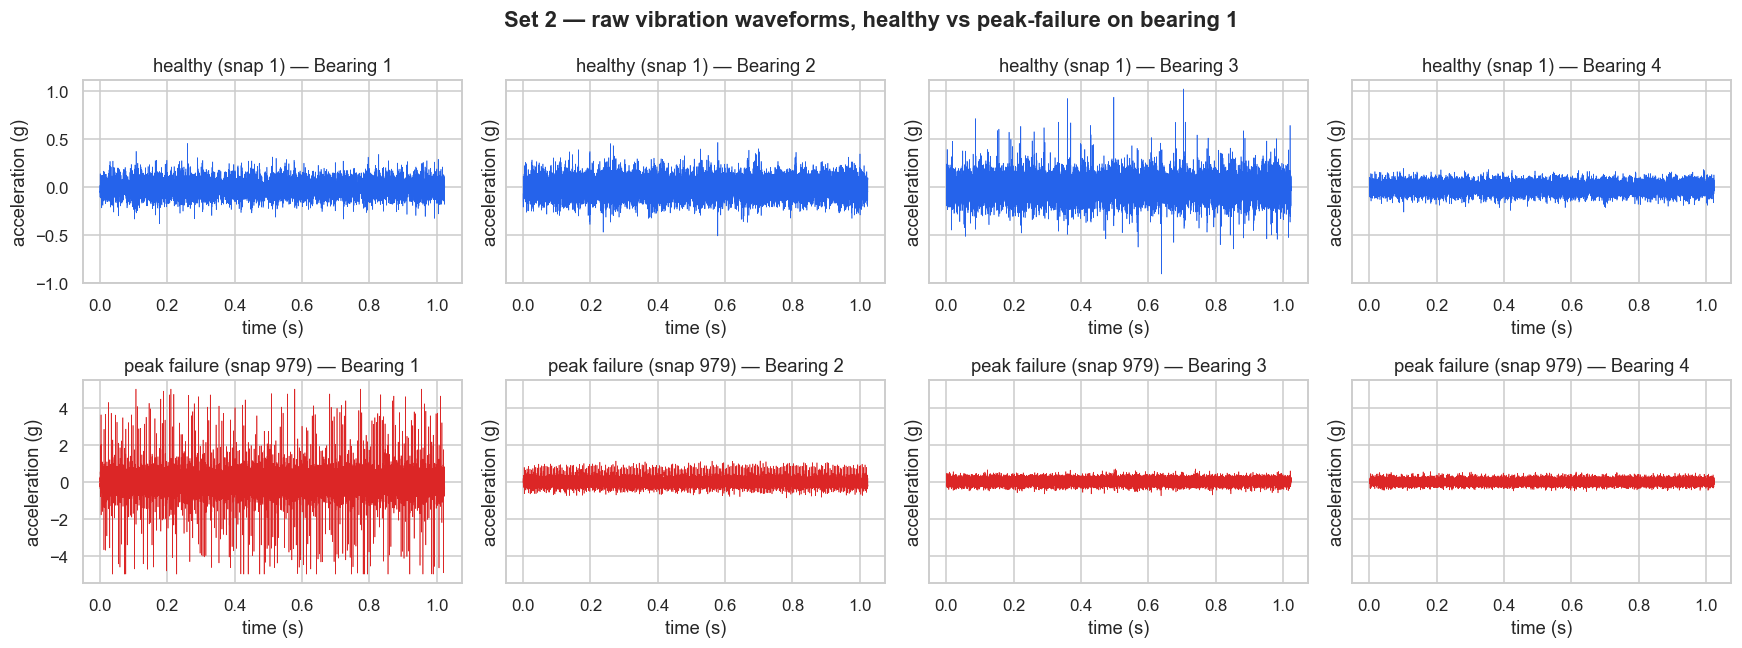

In [6]:
def plot_four_channel_waveform(snap: np.ndarray, title: str, ax_row, color: str):
    t = np.arange(snap.shape[0]) / SAMPLE_RATE_HZ
    for ch in range(snap.shape[1]):
        ax_row[ch].plot(t, snap[:, ch], lw=0.4, color=color)
        ax_row[ch].set_xlabel("time (s)")
        ax_row[ch].set_ylabel("acceleration (g)")
        ax_row[ch].set_title(f"{title} — Bearing {ch + 1}")
    return ax_row


fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey="row")
plot_four_channel_waveform(first_snap, "healthy (snap 1)", axes[0], color="#2563eb")
plot_four_channel_waveform(peak_snap, "peak failure (snap " + str(peak_idx) + ")", axes[1], color="#dc2626")
fig.suptitle("Set 2 — raw vibration waveforms, healthy vs peak-failure on bearing 1", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_waveform_healthy_vs_degraded.png", dpi=130, bbox_inches="tight")
plt.show()

**What to look for.** Bearing 1 (channel 0) should show a dramatic amplitude swing in the degraded snapshot relative to the healthy snapshot — that's the outer-race defect making itself heard. The other bearings stay relatively quiet, which is the ground truth we want our models to recover automatically.

## 4. Frequency-domain view — where is the energy?

Bearings have characteristic fault frequencies (BPFO/BPFI/BSF/FTF) determined by geometry and shaft speed. A healthy bearing has broadband, low-amplitude noise; a defective one concentrates energy at one or two fault harmonics. FFT both snapshots and compare.

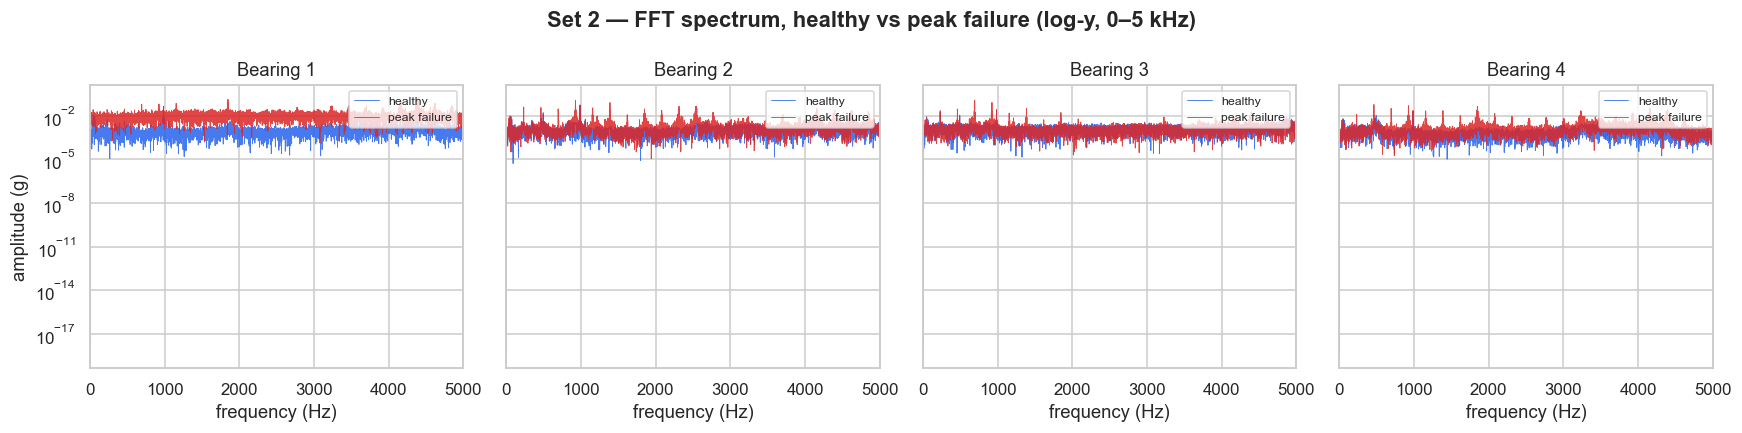

In [7]:
def fft_magnitude(x: np.ndarray, fs: int = SAMPLE_RATE_HZ) -> tuple[np.ndarray, np.ndarray]:
    """Single-sided amplitude spectrum."""
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    mag = np.abs(np.fft.rfft(x - x.mean())) / n
    mag[1:-1] *= 2
    return freqs, mag


fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ch in range(4):
    f, m_h = fft_magnitude(first_snap[:, ch])
    _, m_d = fft_magnitude(peak_snap[:, ch])
    axes[ch].semilogy(f, m_h, lw=0.6, color="#2563eb", label="healthy", alpha=0.85)
    axes[ch].semilogy(f, m_d, lw=0.6, color="#dc2626", label="peak failure", alpha=0.85)
    axes[ch].set_xlim(0, 5000)
    axes[ch].set_xlabel("frequency (Hz)")
    axes[ch].set_title(f"Bearing {ch + 1}")
    axes[ch].legend(loc="upper right", fontsize=8)
axes[0].set_ylabel("amplitude (g)")
fig.suptitle("Set 2 — FFT spectrum, healthy vs peak failure (log-y, 0–5 kHz)", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_fft_healthy_vs_degraded.png", dpi=130, bbox_inches="tight")
plt.show()

**Interpretation.** Watch for B1's spectrum to broaden and pick up sharp peaks in the degraded snapshot. The other bearings should show a more subtle shift — useful for later modelling where we want a model to detect *which* bearing failed, not just whether *any* bearing did.

## 5. Degradation curve — RMS and kurtosis evolution across the full Set 2 timeline

We already computed per-snapshot features in section 2. Time-series of RMS and kurtosis are the canonical "health indicators" in the bearing-prognostics literature.

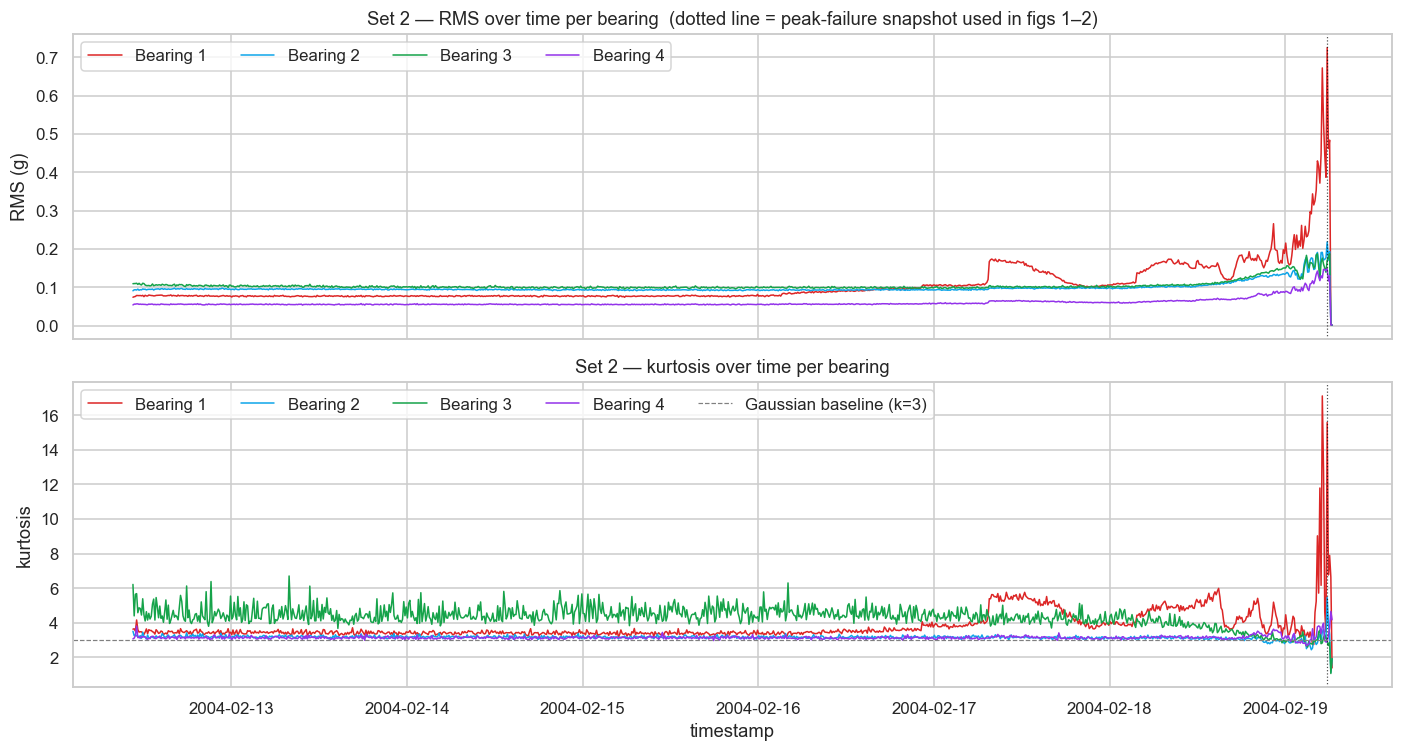

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

bearing_colors = ["#dc2626", "#0ea5e9", "#16a34a", "#9333ea"]

for ch in range(4):
    axes[0].plot(feat_df.index, feat_df[f"rms_b{ch + 1}"], lw=1.0, color=bearing_colors[ch], label=f"Bearing {ch + 1}")
    axes[1].plot(feat_df.index, feat_df[f"kurtosis_b{ch + 1}"], lw=1.0, color=bearing_colors[ch], label=f"Bearing {ch + 1}")

# Mark peak-failure timestamp
peak_ts = feat_df.index[peak_idx]
for ax in axes:
    ax.axvline(peak_ts, color="black", ls=":", lw=0.8, alpha=0.7)

axes[0].set_ylabel("RMS (g)")
axes[0].set_title("Set 2 — RMS over time per bearing  (dotted line = peak-failure snapshot used in figs 1–2)")
axes[0].legend(ncol=4, loc="upper left")

axes[1].set_ylabel("kurtosis")
axes[1].set_xlabel("timestamp")
axes[1].set_title("Set 2 — kurtosis over time per bearing")
axes[1].axhline(3.0, color="grey", ls="--", lw=0.8, label="Gaussian baseline (k=3)")
axes[1].legend(ncol=5, loc="upper left")

fig.tight_layout()
fig.savefig(FIG_DIR / "03_degradation_curves_set2.png", dpi=130, bbox_inches="tight")
plt.show()

**What this should reveal.**

- Bearing 1 RMS climbs sharply in the last ~24 hours of the test — that's the documented outer-race failure.
- Kurtosis (sensitivity to impulsive bursts) typically spikes *earlier* than RMS, then drops back as the defect transitions from spalling to smooth wear. The classic "kurtosis early warning, RMS confirms" pattern.
- Other bearings stay near a flat baseline, which validates that the experimental signal-to-noise is high enough to make this a tractable supervised problem.

These curves are also our first hint at labelling strategy: a binary healthy/degraded split is too coarse. A three-class (healthy / early-fault / severe-fault) labelling driven by kurtosis crossings is more aligned with how the literature on this dataset proceeds.

## 6. Decisions captured in this notebook

1. **Focus on Set 2 for the first modelling pass.** Smaller, cleaner channel-to-bearing mapping, well-documented failure outcome.
2. **Target = bearing 1 health state.** The other three bearings provide useful negative examples.
3. **Labelling strategy = three-class**, with thresholds derived from kurtosis on B1 (defined in notebook 02).
4. **Per-snapshot features as the modelling unit** (one row = one 1-second window), not the raw 20,480-point signal directly. This keeps the baseline tractable; we'll revisit raw-signal models for the deep-learning pass.

Next notebook: `02_feature_engineering.ipynb` — full feature set (time + frequency domain), labelling, train/val/test split with bearing-level holdout.